# Project 3: Unsupervised Learning — Customer Segmentation

## Project Objective

The objective of this project is to segment customers using unsupervised learning techniques.

In this project, we will:
- Prepare and analyze the retail customer dataset.
- Apply Principal Component Analysis (PCA) for dimensionality reduction.
- Use the Elbow Method to identify a suitable number of K-Means clusters.
- Use Silhouette Score to evaluate the clustering quality.
- Build customer segments using K-Means clustering.
- Translate the resulting clusters into actionable business personas.

## Customer Personas and Business Insights

### Cluster 0 — Standard / One-Time Customers

- Customers: 1,178
- Average Orders: 1.00
- Average Spending: 1,057.07
- Average Quantity: 2.95
- Average Recency: 463.69 days

**Business Persona:**  
These customers are primarily one-time or low-frequency buyers.

**Business Action:**  
Use personalized offers, follow-up campaigns, and targeted promotions to encourage repeat purchases.

---

### Cluster 1 — High-Value Repeat Customers

- Customers: 11
- Average Orders: 2.00
- Average Spending: 1,775.98
- Average Quantity: 5.45
- Average Recency: 311.45 days

**Business Persona:**  
These customers show repeat purchasing behavior, higher average quantity, and higher total spending.

**Business Action:**  
Use loyalty rewards, premium offers, personalized recommendations, and retention campaigns for this segment.

---

### Overall Business Insight

The K-Means model identified two distinct customer segments.  
Cluster 0 represents the majority of customers with mostly single purchases, while Cluster 1 represents a small group of repeat and higher-spending customers.

These segments can help businesses design different marketing and customer-retention strategies.

In [48]:
import pandas as pd

df = pd.read_excel("data/raw/Dataset_for_Data_Analytics.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [49]:
df.shape

(1200, 14)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [51]:
df["CustomerID"].nunique()

1189

In [52]:
df["CustomerID"].value_counts().head(10)

CustomerID
C98474    2
C97593    2
C14847    2
C38840    2
C91155    2
C94569    2
C35852    2
C46651    2
C56969    2
C21191    2
Name: count, dtype: int64

In [53]:
customer_features = df.groupby("CustomerID").agg(
    TotalOrders=("OrderID", "count"),
    TotalQuantity=("Quantity", "sum"),
    TotalSpent=("TotalPrice", "sum"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean"),
    AverageItemsInCart=("ItemsInCart", "mean")
).reset_index()

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageOrderValue,AverageUnitPrice,AverageItemsInCart
0,C10002,1,3,1470.03,1470.03,490.01,4.0
1,C10054,1,2,153.48,153.48,76.74,7.0
2,C10126,1,2,1349.80,1349.80,674.90,4.0
3,C10154,1,4,1303.04,1303.04,325.76,8.0
4,C10211,1,5,635.90,635.90,127.18,10.0


In [54]:
product_features = df.groupby("CustomerID").agg(
    UniqueProducts=("Product", "nunique"),
    MostPurchasedProduct=("Product", lambda x: x.mode()[0]),
    UniquePaymentMethods=("PaymentMethod", "nunique"),
    UniqueReferralSources=("ReferralSource", "nunique"),
    UniqueShippingAddresses=("ShippingAddress", "nunique")
).reset_index()

customer_features = customer_features.merge(
    product_features,
    on="CustomerID",
    how="left"
)

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageOrderValue,AverageUnitPrice,AverageItemsInCart,UniqueProducts,MostPurchasedProduct,UniquePaymentMethods,UniqueReferralSources,UniqueShippingAddresses
0,C10002,1,3,1470.03,1470.03,490.01,4.0,1,Printer,1,1,1
1,C10054,1,2,153.48,153.48,76.74,7.0,1,Laptop,1,1,1
2,C10126,1,2,1349.80,1349.80,674.90,4.0,1,Monitor,1,1,1
3,C10154,1,4,1303.04,1303.04,325.76,8.0,1,Desk,1,1,1
4,C10211,1,5,635.90,635.90,127.18,10.0,1,Desk,1,1,1


In [55]:
status_features = df.groupby("CustomerID").agg(
    UniqueOrderStatuses=("OrderStatus", "nunique"),
    DeliveredOrders=("OrderStatus", lambda x: (x == "Delivered").sum()),
    CancelledOrders=("OrderStatus", lambda x: (x == "Cancelled").sum()),
    ReturnedOrders=("OrderStatus", lambda x: (x == "Returned").sum()),
    ShippedOrders=("OrderStatus", lambda x: (x == "Shipped").sum()),
    CouponUsageCount=("CouponCode", "count"),
    UniqueCouponsUsed=("CouponCode", "nunique")
).reset_index()

customer_features = customer_features.merge(
    status_features,
    on="CustomerID",
    how="left"
)

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageOrderValue,AverageUnitPrice,AverageItemsInCart,UniqueProducts,MostPurchasedProduct,UniquePaymentMethods,UniqueReferralSources,UniqueShippingAddresses,UniqueOrderStatuses,DeliveredOrders,CancelledOrders,ReturnedOrders,ShippedOrders,CouponUsageCount,UniqueCouponsUsed
0,C10002,1,3,1470.03,1470.03,490.01,4.0,1,Printer,1,1,1,1,0,0,1,0,1,1
1,C10054,1,2,153.48,153.48,76.74,7.0,1,Laptop,1,1,1,1,0,0,1,0,1,1
2,C10126,1,2,1349.80,1349.80,674.90,4.0,1,Monitor,1,1,1,1,0,0,0,1,1,1
3,C10154,1,4,1303.04,1303.04,325.76,8.0,1,Desk,1,1,1,1,0,0,0,1,1,1
4,C10211,1,5,635.90,635.90,127.18,10.0,1,Desk,1,1,1,1,0,1,0,0,1,1


In [56]:
date_features = df.groupby("CustomerID").agg(
    FirstPurchaseDate=("Date", "min"),
    LastPurchaseDate=("Date", "max")
).reset_index()

date_features["CustomerLifespanDays"] = (
    date_features["LastPurchaseDate"] - date_features["FirstPurchaseDate"]
).dt.days

date_features["PurchaseRecencyDays"] = (
    df["Date"].max() - date_features["LastPurchaseDate"]
).dt.days

customer_features = customer_features.merge(
    date_features,
    on="CustomerID",
    how="left"
)

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageOrderValue,AverageUnitPrice,AverageItemsInCart,UniqueProducts,MostPurchasedProduct,UniquePaymentMethods,...,DeliveredOrders,CancelledOrders,ReturnedOrders,ShippedOrders,CouponUsageCount,UniqueCouponsUsed,FirstPurchaseDate,LastPurchaseDate,CustomerLifespanDays,PurchaseRecencyDays
0,C10002,1,3,1470.03,1470.03,490.01,4.0,1,Printer,1,...,0,0,1,0,1,1,2023-10-16,2023-10-16,0,623
1,C10054,1,2,153.48,153.48,76.74,7.0,1,Laptop,1,...,0,0,1,0,1,1,2024-10-14,2024-10-14,0,259
2,C10126,1,2,1349.80,1349.80,674.90,4.0,1,Monitor,1,...,0,0,0,1,1,1,2023-06-18,2023-06-18,0,743
3,C10154,1,4,1303.04,1303.04,325.76,8.0,1,Desk,1,...,0,0,0,1,1,1,2024-07-29,2024-07-29,0,336
4,C10211,1,5,635.90,635.90,127.18,10.0,1,Desk,1,...,0,1,0,0,1,1,2024-05-09,2024-05-09,0,417


In [57]:
pca_features = customer_features.select_dtypes(include="number").copy()

pca_features.head()

,TotalOrders,TotalQuantity,TotalSpent,AverageOrderValue,AverageUnitPrice,AverageItemsInCart,UniqueProducts,UniquePaymentMethods,UniqueReferralSources,UniqueShippingAddresses,UniqueOrderStatuses,DeliveredOrders,CancelledOrders,ReturnedOrders,ShippedOrders,CouponUsageCount,UniqueCouponsUsed,CustomerLifespanDays,PurchaseRecencyDays
0,1,3,1470.03,1470.03,490.01,4.0,1,1,1,1,1,0,0,1,0,1,1,0,623
1,1,2,153.48,153.48,76.74,7.0,1,1,1,1,1,0,0,1,0,1,1,0,259
2,1,2,1349.80,1349.80,674.90,4.0,1,1,1,1,1,0,0,0,1,1,1,0,743
3,1,4,1303.04,1303.04,325.76,8.0,1,1,1,1,1,0,0,0,1,1,1,0,336
4,1,5,635.90,635.90,127.18,10.0,1,1,1,1,1,0,1,0,0,1,1,0,417


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(pca_features)

scaled_features.shape

(1189, 19)

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_features)

pca_data.shape

(1189, 2)

In [60]:
explained_variance = pca.explained_variance_ratio_

print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("Total Explained Variance:", explained_variance.sum())

PC1: 0.3257103529738774
PC2: 0.16528012183589577
Total Explained Variance: 0.4909904748097732


In [61]:
pca_3d = PCA(n_components=3)

pca_3d_data = pca_3d.fit_transform(scaled_features)

print("PCA 3D Shape:", pca_3d_data.shape)
print("Total Explained Variance:", pca_3d.explained_variance_ratio_.sum())

PCA 3D Shape: (1189, 3)
Total Explained Variance: 0.5941954438837431


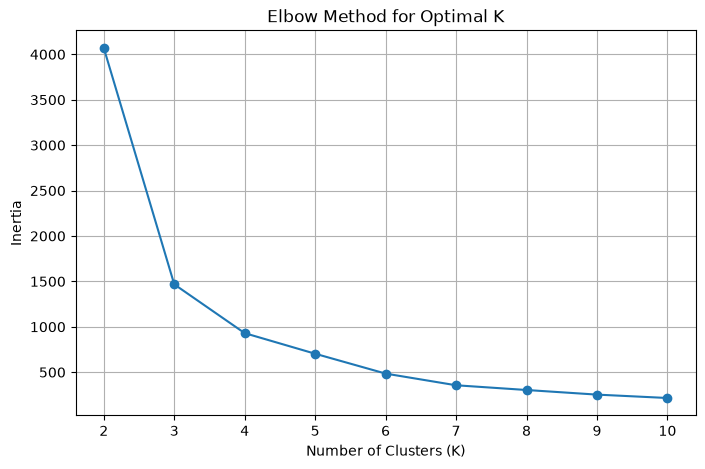

In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [63]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

K=2: Silhouette Score=0.9185
K=3: Silhouette Score=0.6018
K=4: Silhouette Score=0.5234
K=5: Silhouette Score=0.4920
K=6: Silhouette Score=0.4903
K=7: Silhouette Score=0.4992
K=8: Silhouette Score=0.4694
K=9: Silhouette Score=0.4706
K=10: Silhouette Score=0.4574


In [64]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(pca_data)

customer_features["Cluster"] = cluster_labels

customer_features["Cluster"].value_counts().sort_index()

Cluster
0    1178
1      11
Name: count, dtype: int64

In [65]:
cluster_profile = customer_features.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    AvgOrders=("TotalOrders", "mean"),
    AvgQuantity=("TotalQuantity", "mean"),
    AvgSpent=("TotalSpent", "mean"),
    AvgOrderValue=("AverageOrderValue", "mean"),
    AvgUnitPrice=("AverageUnitPrice", "mean"),
    AvgItemsInCart=("AverageItemsInCart", "mean"),
    AvgUniqueProducts=("UniqueProducts", "mean"),
    AvgRecencyDays=("PurchaseRecencyDays", "mean")
).round(2)

cluster_profile

,Customers,AvgOrders,AvgQuantity,AvgSpent,AvgOrderValue,AvgUnitPrice,AvgItemsInCart,AvgUniqueProducts,AvgRecencyDays
Cluster,,,,,,,,,
0,1178,1.0,2.95,1057.07,1057.07,357.13,5.49,1.00,463.69
1,11,2.0,5.45,1775.98,887.99,317.79,5.05,1.73,311.45


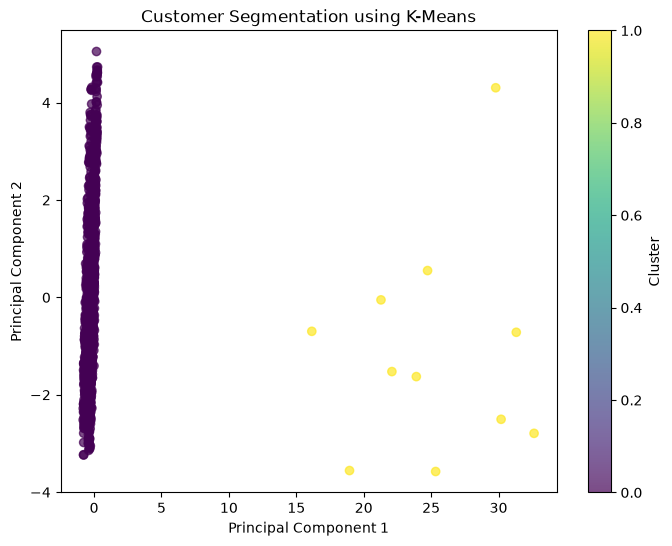

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.show()

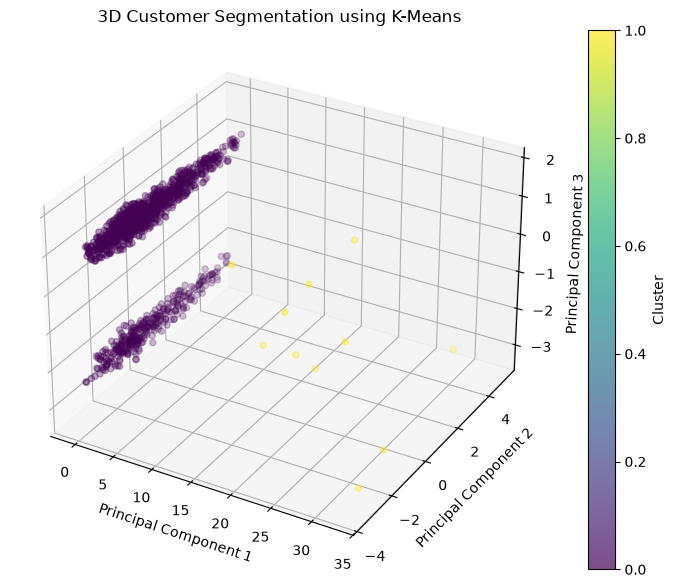

In [67]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_3d_data[:, 0],
    pca_3d_data[:, 1],
    pca_3d_data[:, 2],
    c=cluster_labels,
    alpha=0.7
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D Customer Segmentation using K-Means")

plt.colorbar(scatter, ax=ax, label="Cluster")
plt.show()

In [68]:
customer_features.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

print("Customer segmentation results saved successfully.")

Customer segmentation results saved successfully.


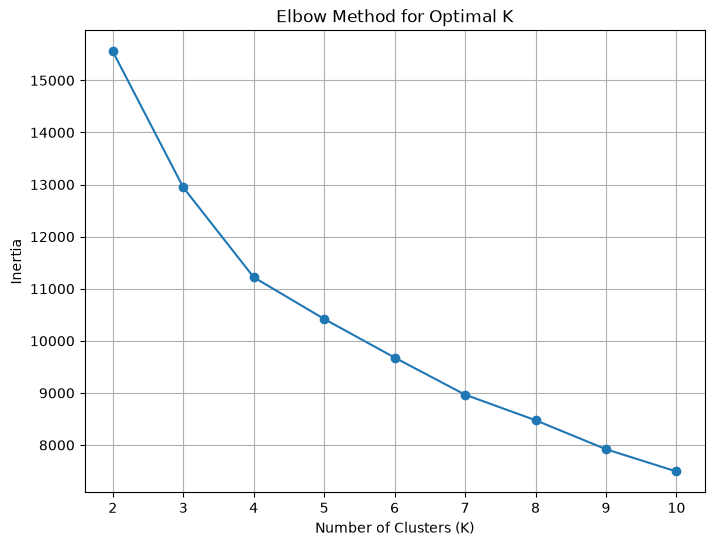

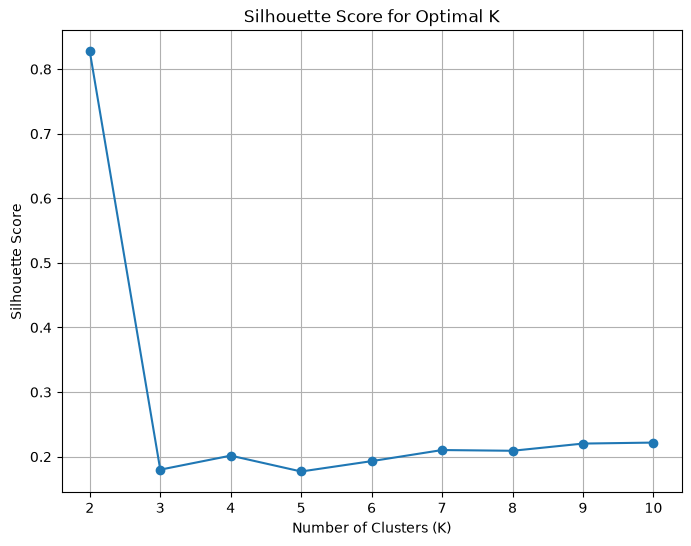

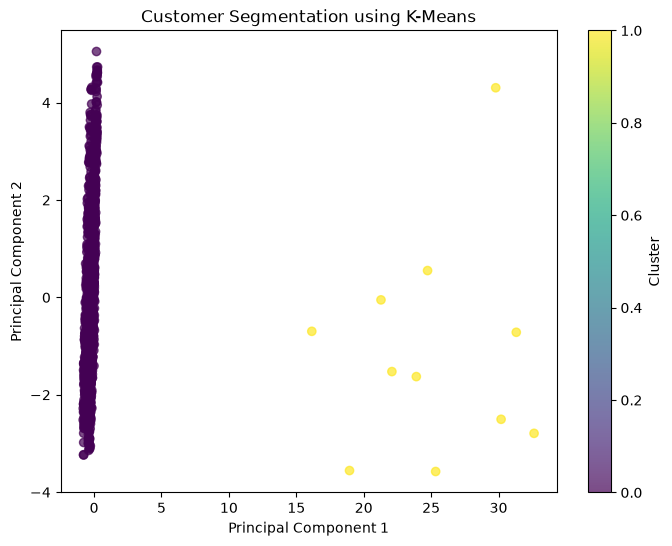

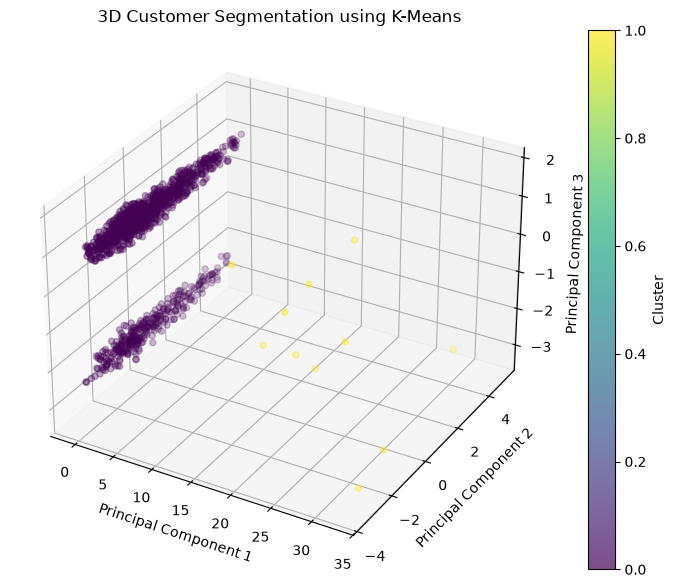

All visualizations saved successfully.


In [69]:
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

os.makedirs("visualizations", exist_ok=True)

# 1. Elbow Method
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_features)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.savefig("visualizations/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()


# 2. Silhouette Score
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.grid(True)
plt.savefig("visualizations/silhouette_score.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. 2D PCA Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.savefig(
    "visualizations/customer_segmentation_2d.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 4. 3D PCA Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_3d_data[:, 0],
    pca_3d_data[:, 1],
    pca_3d_data[:, 2],
    c=cluster_labels,
    alpha=0.7
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D Customer Segmentation using K-Means")

plt.colorbar(scatter, ax=ax, label="Cluster")

plt.savefig(
    "visualizations/customer_segmentation_3d.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("All visualizations saved successfully.")

In [70]:
cluster_profile.to_csv(
    "output/cluster_profiles.csv",
    index=True
)

print("Cluster profiles saved successfully.")

Cluster profiles saved successfully.
